In [6]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Path to dataset files: /kaggle/input/chest-xray-pneumonia


In [7]:
import shutil
import os

# 1. Descargar (o localizar si ya está descargado)
print("Localizando dataset...")
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
print(f"Dataset encontrado en: {path}")

# 2. Definir tu carpeta de destino local
project_data_dir = os.path.join(os.getcwd(), "data")

# 3. Mover los archivos
# El dataset suele venir con una subcarpeta redundante 'chest_xray', vamos a limpiarlo.
source_folder = os.path.join(path, "chest_xray")

if os.path.exists(project_data_dir):
    print(f"¡Atención! La carpeta '{project_data_dir}' ya existe. Bórrala si quieres recargar los datos.")
else:
    print(f"Copiando archivos a {project_data_dir} (esto puede tardar unos segundos)...")
    try:
        # Copiamos todo el contenido a la carpeta data del proyecto
        shutil.copytree(source_folder, project_data_dir)
        print("✅ ¡Datos copiados exitosamente!")

        # Verificar estructura
        print("\nEstructura de carpetas creada:")
        for root, dirs, files in os.walk(project_data_dir):
            level = root.replace(project_data_dir, '').count(os.sep)
            indent = ' ' * 4 * (level)
            print(f"{indent}{os.path.basename(root)}/")
            subindent = ' ' * 4 * (level + 1)
            # Solo mostramos las primeras carpetas para no llenar la pantalla
            if level < 2:
                pass
    except Exception as e:
        print(f"Error al copiar: {e}")
        print("Intenta copiar manualmente la carpeta 'chest_xray' del path original a tu carpeta 'data'.")

Localizando dataset...
Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Dataset encontrado en: /kaggle/input/chest-xray-pneumonia
¡Atención! La carpeta '/content/data' ya existe. Bórrala si quieres recargar los datos.


In [8]:
import torch
from torchvision import datasets, transforms
import os

# Definir ruta
data_dir = './data'
train_dir = os.path.join(data_dir, 'train')

# Transformaciones básicas (ViT necesita 224x224)
data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

try:
    # ImageFolder es la herramienta estándar para leer carpetas con nombres de clases
    train_dataset = datasets.ImageFolder(train_dir, transform=data_transforms)

    print(f"✅ ¡Éxito! PyTorch pudo leer el dataset.")
    print(f"Imágenes de entrenamiento encontradas: {len(train_dataset)}")
    print(f"Clases detectadas: {train_dataset.classes}") # Debería decir ['NORMAL', 'PNEUMONIA']

    # Verificamos una imagen
    img, label = train_dataset[0]
    print(f"Forma del tensor de una imagen: {img.shape}") # Debería ser torch.Size([3, 224, 224])

except FileNotFoundError:
    print("❌ Error: No se encontró la carpeta 'data/train'. Asegúrate de haber corrido el paso 1.")
except Exception as e:
    print(f"❌ Ocurrió un error inesperado: {e}")

✅ ¡Éxito! PyTorch pudo leer el dataset.
Imágenes de entrenamiento encontradas: 5216
Clases detectadas: ['NORMAL', 'PNEUMONIA']
Forma del tensor de una imagen: torch.Size([3, 224, 224])


In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import timm # Nuestra librería de modelos SOTA
from tqdm import tqdm # Para la barra de progreso
import os

# --- CONFIGURACIÓN ---
# Si tienes tarjeta gráfica NVIDIA, usará 'cuda'. Si no, 'cpu' (será más lento)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 16    # Cantidad de fotos que procesa a la vez (bájalo a 8 si te da error de memoria)
EPOCHS = 4         # Cuántas veces revisará todo el dataset (3 suele bastar para Fine-Tuning)
LEARNING_RATE = 2e-5 # Velocidad de aprendizaje (muy bajita para no romper lo que el modelo ya sabe)
DATA_DIR = './data'

def main():
    print(f"🚀 Iniciando entrenamiento en: {DEVICE}")

    # 1. PREPARAR LOS DATOS (Transformaciones)
    # Los modelos ViT suelen necesitar imágenes de 224x224
    data_transforms = {
        'train': transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.RandomHorizontalFlip(), # Data Augmentation (espejo) para que aprenda mejor
            transforms.ToTensor(),
            transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
        ]),
        'test': transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
        ]),
    }

    # Cargar los datasets
    # Nota: Usamos la carpeta 'test' como validación porque la carpeta 'val' original es muy pequeña
    train_dataset = datasets.ImageFolder(os.path.join(DATA_DIR, 'train'), data_transforms['train'])
    val_dataset = datasets.ImageFolder(os.path.join(DATA_DIR, 'test'), data_transforms['test'])

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

    print(f"📸 Imágenes de entrenamiento: {len(train_dataset)}")
    print(f"📸 Imágenes de validación: {len(val_dataset)}")

    # 2. CARGAR EL MODELO (VISION TRANSFORMER)
    # 'vit_base_patch16_224': Es el estándar.
    # num_classes=2: Lo forzamos a tener solo 2 salidas (Normal vs Neumonía)
    print("🧠 Descargando y cargando el modelo ViT...")
    model = timm.create_model('vit_base_patch16_224', pretrained=True, num_classes=2)
    model = model.to(DEVICE)

    # 3. CONFIGURAR MOTORES (Pérdida y Optimizador)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    # 4. BUCLE DE ENTRENAMIENTO
    best_acc = 0.0

    for epoch in range(EPOCHS):
        print(f"\n--- Epoch {epoch+1}/{EPOCHS} ---")

        # --- FASE DE ENTRENAMIENTO ---
        model.train()
        train_loss = 0
        train_correct = 0

        # Barra de progreso
        loop = tqdm(train_loader, desc="Entrenando")

        for images, labels in loop:
            images, labels = images.to(DEVICE), labels.to(DEVICE)

            # A. Forward (Predicción)
            outputs = model(images)
            loss = criterion(outputs, labels)

            # B. Backward (Aprendizaje)
            optimizer.zero_grad() # Limpiar basura anterior
            loss.backward()       # Calcular errores
            optimizer.step()      # Ajustar neuronas

            # Métricas
            train_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            train_correct += torch.sum(preds == labels.data)

            # Actualizar barra
            loop.set_postfix(loss=loss.item())

        train_acc = train_correct.double() / len(train_dataset)
        print(f"Resultados Train -> Loss: {train_loss/len(train_loader):.4f} | Acc: {train_acc:.4f}")

        # --- FASE DE VALIDACIÓN ---
        model.eval() # Modo evaluación (apaga el aprendizaje)
        val_correct = 0

        with torch.no_grad(): # No necesitamos calcular gradientes aquí (ahorra memoria)
            for images, labels in val_loader:
                images, labels = images.to(DEVICE), labels.to(DEVICE)
                outputs = model(images)
                _, preds = torch.max(outputs, 1)
                val_correct += torch.sum(preds == labels.data)

        val_acc = val_correct.double() / len(val_dataset)
        print(f"Resultados Val   -> Acc: {val_acc:.4f}")

        # Guardar el mejor modelo
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), "modelo_vit_neumonia.pth")
            print("💾 ¡Nuevo récord! Modelo guardado.")

    print("\n✅ ¡Entrenamiento finalizado!")

if __name__ == '__main__':
    main()

🚀 Iniciando entrenamiento en: cuda
📸 Imágenes de entrenamiento: 5216
📸 Imágenes de validación: 624
🧠 Descargando y cargando el modelo ViT...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]


--- Epoch 1/4 ---


Entrenando: 100%|██████████| 326/326 [04:08<00:00,  1.31it/s, loss=0.0346]


...

Resultados Train -> Loss: 0.0399 | Acc: 0.9858
Resultados Val   -> Acc: 0.8349
💾 ¡Nuevo récord! Modelo guardado.

--- Epoch 3/4 ---


Entrenando: 100%|██████████| 326/326 [04:14<00:00,  1.28it/s, loss=0.00268]


Resultados Train -> Loss: 0.0241 | Acc: 0.9910
Resultados Val   -> Acc: 0.7292

--- Epoch 4/4 ---


Entrenando: 100%|██████████| 326/326 [04:12<00:00,  1.29it/s, loss=0.000522]


Resultados Train -> Loss: 0.0211 | Acc: 0.9927
Resultados Val   -> Acc: 0.8510
💾 ¡Nuevo récord! Modelo guardado.

✅ ¡Entrenamiento finalizado!


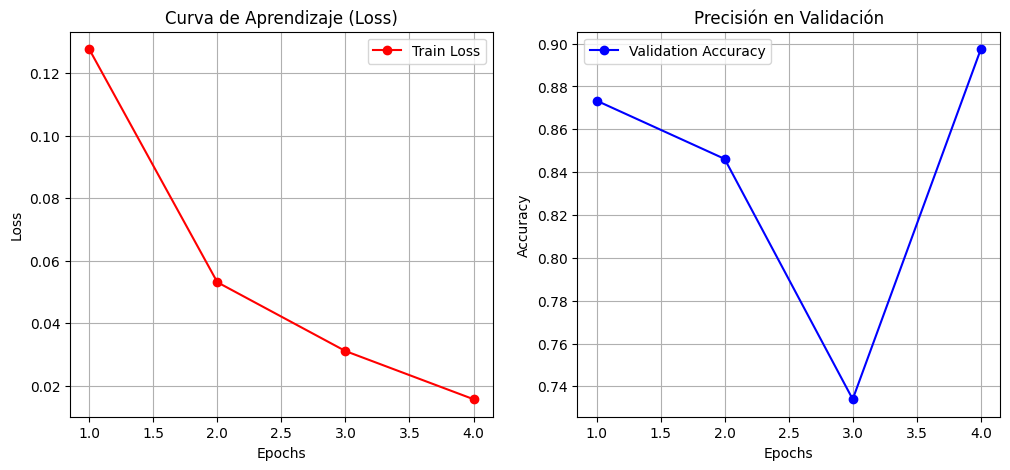

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import torch
import timm
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import numpy as np
import os

# --- 1. GRAFICAR HISTORIAL DE ENTRENAMIENTO (Datos Manuales del Log) ---
# Copié los datos de tu log para no tener que re-entrenar
epochs = [1, 2, 3, 4]
train_loss = [0.1276, 0.0531, 0.0311, 0.0157]
val_acc = [0.8734, 0.8462, 0.7340, 0.8974]

plt.figure(figsize=(12, 5))

# Gráfica de Pérdida (Loss) - Queremos que baje
plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss, 'r-o', label='Train Loss')
plt.title('Curva de Aprendizaje (Loss)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

# Gráfica de Precisión (Accuracy) - Queremos que suba
plt.subplot(1, 2, 2)
plt.plot(epochs, val_acc, 'b-o', label='Validation Accuracy')
plt.title('Precisión en Validación')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()

plt.show()





In [13]:
# --- 2. EVALUACIÓN PROFUNDA (Cargar Modelo y Predecir) ---
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DATA_DIR = './data'

# Transformaciones (Solo Resize y Tensor, sin Augmentation para validar)
val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

# Cargar Dataset de Validación
val_dataset = datasets.ImageFolder(os.path.join(DATA_DIR, 'test'), val_transforms)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

# Cargar tu Modelo Guardado
print("🔄 Cargando el mejor modelo guardado...")
model = timm.create_model('vit_base_patch16_224', num_classes=2)
model.load_state_dict(torch.load("modelo_vit_neumonia.pth"))
model = model.to(DEVICE)
model.eval()

# Obtener predicciones
all_preds = []
all_labels = []

# Guardaremos las imágenes que fallaron para mostrarlas
misclassified_images = [] # Tupla: (imagen, predicción, real)

print("🔍 Analizando dataset de validación...")
with torch.no_grad():
    for i, (images, labels) in enumerate(val_loader):
        images_dev = images.to(DEVICE)
        outputs = model(images_dev)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

        # Buscar errores en este batch
        mismatches = preds.cpu() != labels
        if mismatches.any():
            # Índices dentro del batch donde falló
            error_indices = mismatches.nonzero(as_tuple=True)[0]
            for idx in error_indices:
                if len(misclassified_images) < 10: # Guardar solo las primeras 10 para no saturar
                    img = images[idx].permute(1, 2, 0).cpu().numpy()
                    # Des-normalizar para que se vea bien (revertir el 0.5, 0.5, 0.5)
                    img = img * 0.5 + 0.5
                    misclassified_images.append((img, preds[idx].item(), labels[idx].item()))



🔄 Cargando el mejor modelo guardado...
🔍 Analizando dataset de validación...


In [14]:
# Guardaremos las imágenes que fallaron para mostrarlas
misclassified_images = [] # Tupla: (imagen, predicción, real)

print("🔍 Analizando dataset de validación...")
with torch.no_grad():
    for i, (images, labels) in enumerate(val_loader):
        images_dev = images.to(DEVICE)
        outputs = model(images_dev)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

        # Buscar errores en este batch
        mismatches = preds.cpu() != labels
        if mismatches.any():
            # Índices dentro del batch donde falló
            error_indices = mismatches.nonzero(as_tuple=True)[0]
            for idx in error_indices:
                if len(misclassified_images) < 10: # Guardar solo las primeras 10 para no saturar
                    img = images[idx].permute(1, 2, 0).cpu().numpy()
                    # Des-normalizar para que se vea bien (revertir el 0.5, 0.5, 0.5)
                    img = img * 0.5 + 0.5
                    misclassified_images.append((img, preds[idx].item(), labels[idx].item()))

🔍 Analizando dataset de validación...


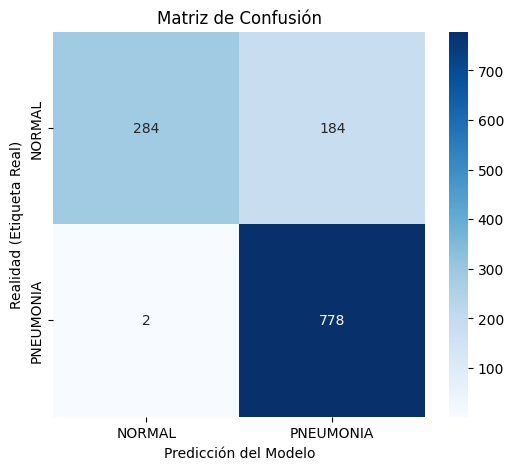


📊 Reporte de Clasificación:

              precision    recall  f1-score   support

      NORMAL       0.99      0.61      0.75       468
   PNEUMONIA       0.81      1.00      0.89       780

    accuracy                           0.85      1248
   macro avg       0.90      0.80      0.82      1248
weighted avg       0.88      0.85      0.84      1248



In [15]:
# --- 3. MATRIZ DE CONFUSIÓN ---
cm = confusion_matrix(all_labels, all_preds)
class_names = val_dataset.classes # ['NORMAL', 'PNEUMONIA']

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicción del Modelo')
plt.ylabel('Realidad (Etiqueta Real)')
plt.title('Matriz de Confusión')
plt.show()

print("\n📊 Reporte de Clasificación:\n")
print(classification_report(all_labels, all_preds, target_names=class_names))


🖼️ Mostrando 10 ejemplos de errores cometidos:


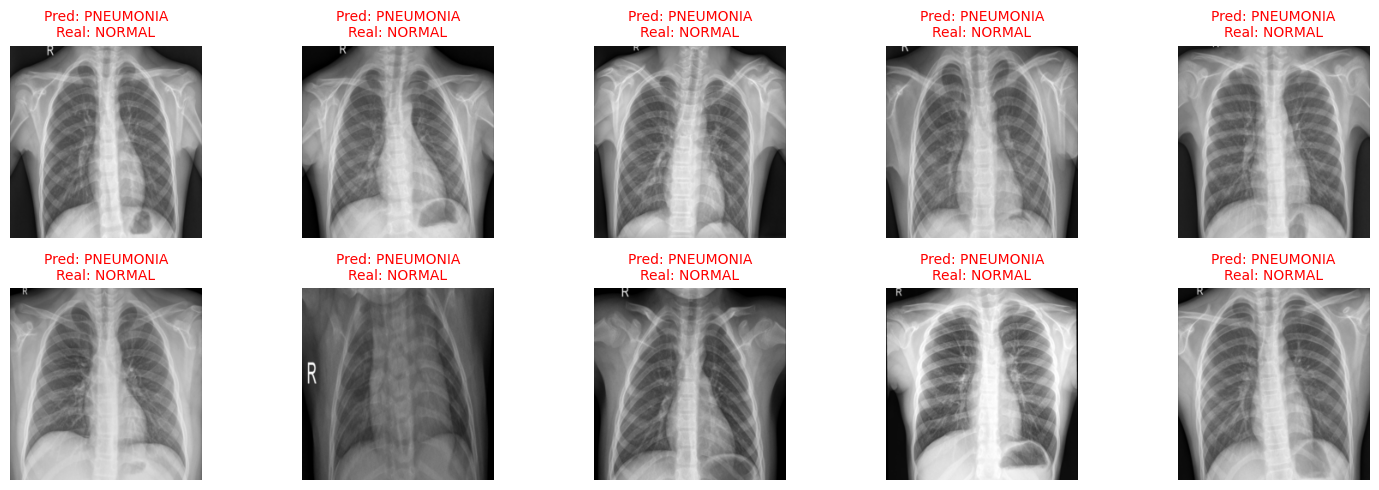

In [16]:
# --- 4. MOSTRAR ERRORES (Falsos Positivos/Negativos) ---
if misclassified_images:
    print(f"\n🖼️ Mostrando {len(misclassified_images)} ejemplos de errores cometidos:")
    plt.figure(figsize=(15, 5))
    for i, (img, pred, label) in enumerate(misclassified_images):
        plt.subplot(2, 5, i+1)
        plt.imshow(img)
        plt.axis('off')
        # Colorear título: Rojo = Error
        pred_label = class_names[pred]
        real_label = class_names[label]
        plt.title(f"Pred: {pred_label}\nReal: {real_label}", color='red', fontsize=10)
    plt.tight_layout()
    plt.show()
else:
    print("¡Increíble! No hubo errores en las primeras imágenes revisadas.")

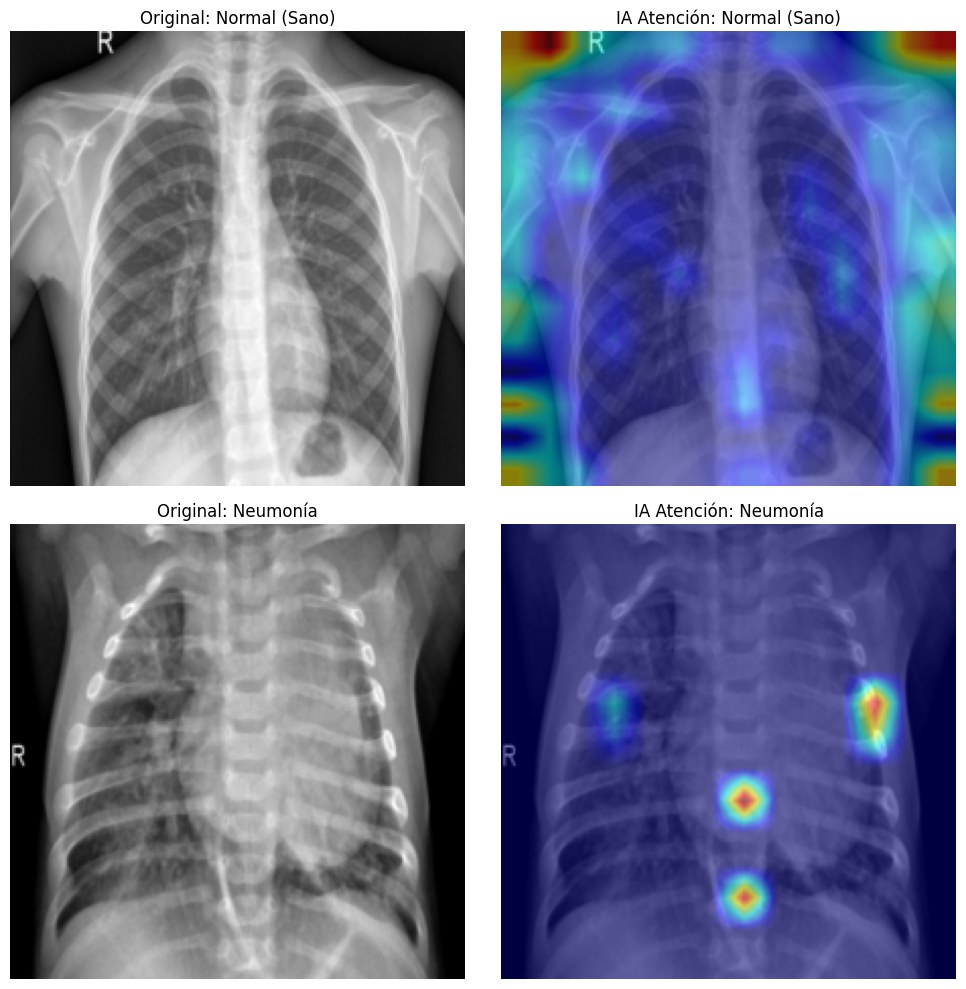

In [23]:
import matplotlib.pyplot as plt
import torch
import numpy as np
from pytorch_grad_cam.utils.image import show_cam_on_image

# --- 1. Función auxiliar para encontrar índices por clase ---
def find_index_by_label(dataset, target_label):
    """Busca el primer índice en el dataset que coincida con la etiqueta dada."""
    for i in range(len(dataset)):
        _, label = dataset[i]
        # Aseguramos que la etiqueta sea un entero (a veces viene como tensor)
        if torch.is_tensor(label):
            label = label.item()
        if label == target_label:
            return i
    return None

# --- 2. Configuración de Visualización Comparativa ---
def compare_normal_vs_pneumonia(model, dataset):
    model.eval()

    # Definimos las etiquetas (Asumiendo 0=Normal, 1=Pneumonia)
    labels_map = {0: "Normal (Sano)", 1: "Neumonía"}

    # Buscamos una imagen de cada tipo
    idx_normal = find_index_by_label(dataset, 0)
    idx_pneumonia = find_index_by_label(dataset, 1)

    indices = [idx_normal, idx_pneumonia]

    # Configurar GradCAM (Reusamos la función reshape_transform definida anteriormente)
    # Intentamos detectar la capa final automáticamente
    try:
        target_layers = [model.encoder.layers[-1].ln_1]
    except AttributeError:
        try:
            target_layers = [model.blocks[-1].norm1]
        except:
            print("Error: Ajusta 'target_layers' manualmente.")
            return

    cam = GradCAM(model=model, target_layers=target_layers, reshape_transform=reshape_transform)

    # Crear la figura 2x2
    fig, axes = plt.subplots(2, 2, figsize=(10, 10))

    for row, idx in enumerate(indices):
        img_tensor, label = dataset[idx]
        if torch.is_tensor(label): label = label.item()

        # Preprocesar imagen para visualización (Fondo)
        rgb_img = img_tensor.permute(1, 2, 0).numpy()
        rgb_img = (rgb_img - rgb_img.min()) / (rgb_img.max() - rgb_img.min())

        # Generar Grad-CAM
        grayscale_cam = cam(input_tensor=img_tensor.unsqueeze(0), targets=None)
        grayscale_cam = grayscale_cam[0, :]

        # Superponer mapa de calor
        visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

        # --- Plotear Original ---
        axes[row, 0].imshow(rgb_img)
        axes[row, 0].set_title(f"Original: {labels_map[label]}")
        axes[row, 0].axis('off')

        # --- Plotear Grad-CAM ---
        axes[row, 1].imshow(visualization)
        axes[row, 1].set_title(f"IA Atención: {labels_map[label]}")
        axes[row, 1].axis('off')

    plt.tight_layout()
    plt.show()

# --- EJECUTAR ---
# Asegúrate de pasar tu dataset de validación o test
compare_normal_vs_pneumonia(model, val_dataset)

delete all files when finish

In [ ]:
import shutil
import os

def eliminar_dataset(ruta_carpeta='./data'):
    # Verificamos si existe para no dar errores
    if os.path.exists(ruta_carpeta):
        try:
            print(f"🗑️ Eliminando dataset en '{ruta_carpeta}' para liberar espacio...")
            shutil.rmtree(ruta_carpeta) # Esto borra la carpeta y todo lo de adentro
            print("✅ ¡Limpieza completada! Espacio recuperado.")
        except Exception as e:
            print(f"❌ Error al eliminar: {e}")
    else:
        print("⚠️ La carpeta ya no existe o la ruta es incorrecta.")

if __name__ == "__main__":
    confirmacion = input("¿Estás seguro de borrar TODAS las imágenes en ./data? (s/n): ")
    if confirmacion.lower() == 's':
        eliminar_dataset()
    else:
        print("Operación cancelada.")

¿Estás seguro de borrar TODAS las imágenes en ./data? (s/n): s
⚠️ La carpeta ya no existe o la ruta es incorrecta.
